# Rossmann Sales — Red Neuronal con Entradas Heterogéneas
**Persona:** Oscar &nbsp;|&nbsp; **Equipo:** Oscar · Dani · Fernando

---
Arquitectura many-to-one: rama LSTM (serie temporal) + rama densa (embeddings estáticos).  
Target: `log1p(Sales)` normalizado por tienda. Tiendas objetivo: `[1, 2, 3, 4, 5, 562, 682, 733, 769]`.

## 0 · Imports y semilla

In [1]:
import sys
import os

# Añadir raíz del proyecto al path para importar src/
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

import src.preprocessing as prep
import src.evaluate as ev
import src.model as mdl

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_DIR    = os.path.join(PROJECT_ROOT, "data")
OUTPUTS_DIR = os.path.join(PROJECT_ROOT, "outputs")

print(f"TensorFlow {tf.__version__} | NumPy {np.__version__}")
print(f"GPU disponible: {len(tf.config.list_physical_devices('GPU'))} dispositivo(s)")

TensorFlow 2.21.0 | NumPy 2.3.3
GPU disponible: 0 dispositivo(s)


## 1 · Carga de datos

In [2]:
train_raw, store_raw = prep.load_raw_data(DATA_DIR)

print(f"train: {train_raw.shape} | {train_raw.Date.min().date()} → {train_raw.Date.max().date()}")
print(f"store: {store_raw.shape}")
train_raw.head(3)

train: (1001599, 10) | 2013-01-01 → 2015-07-17
store: (1115, 10)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Id
0,1,5,2015-07-17,4852,519,1,1,0,0,303445
1,2,5,2015-07-17,4518,495,1,1,0,1,959585
2,3,5,2015-07-17,6679,673,1,1,0,1,739744


## 2 · EDA — Análisis exploratorio

Objetivo: entender la distribución del target, patrones temporales y diferencias entre tiendas **antes** de construir el modelo.  
Las 9 tiendas objetivo son `TARGET_STORES = [1, 2, 3, 4, 5, 562, 682, 733, 769]`.

In [3]:
# Resumen de datos + estadisticas clave de las 9 tiendas objetivo
n = len(train_raw)
n_closed   = (train_raw['Open'] == 0).sum()
n_zero_open = ((train_raw['Open'] == 1) & (train_raw['Sales'] == 0)).sum()
print(f'train {train_raw.shape}  |  {train_raw["Date"].min().date()} a {train_raw["Date"].max().date()}  |  nulos: ninguno')
print(f'store {store_raw.shape}  |  nulos: CompetitionOpenSince* 354, PromoInterval 544, CompetitionDistance 3')
print(f'\nclean_train: -{n_closed:,} Open==0 ({n_closed/n:.1%})  |  -{n_zero_open} Sales==0 open  |  utiles: {n-n_closed-n_zero_open:,} ({(n-n_closed-n_zero_open)/n:.1%})')

# Tabla unificada: estadisticas de ventas + metadatos de tienda
tgt = train_raw[train_raw['Store'].isin(ev.TARGET_STORES) & (train_raw['Open'] == 1)]
stats = tgt.groupby('Store')['Sales'].agg(dias='count', media='mean', std='std').round(0)
stats['cv_%'] = (stats['std'] / stats['media'] * 100).round(1)
meta = store_raw[store_raw['Store'].isin(ev.TARGET_STORES)].set_index('Store')
stats = stats.join(meta[['StoreType', 'Assortment', 'Promo2', 'CompetitionDistance']])
display(stats)

promo_mean = tgt.groupby('Promo')['Sales'].mean()
print(f'\nPromo uplift: +{promo_mean[1]/promo_mean[0]-1:.0%}  |  '
      f'Escala: T562 {stats.loc[562,"media"]:.0f}€  vs  T1 {stats.loc[1,"media"]:.0f}€  '
      f'(ratio {stats.loc[562,"media"]/stats.loc[1,"media"]:.1f}x)')

train (1001599, 10)  |  2013-01-01 a 2015-07-17  |  nulos: ninguno
store (1115, 10)  |  nulos: CompetitionOpenSince* 354, PromoInterval 544, CompetitionDistance 3

clean_train: -170,627 Open==0 (17.0%)  |  -54 Sales==0 open  |  utiles: 830,918 (83.0%)


,dias,media,std,cv_%,StoreType,Assortment,Promo2,CompetitionDistance
Store,,,,,,,,
1,769,4763.0,1015.0,21.3,c,a,0,1270.0
2,772,4956.0,1615.0,32.6,a,a,1,570.0
3,767,6950.0,2199.0,31.6,a,a,1,14130.0
4,772,9633.0,1939.0,20.1,c,c,0,620.0
5,767,4682.0,1769.0,37.8,a,a,0,29910.0
562,928,17980.0,2933.0,16.3,b,c,0,1210.0
682,928,11218.0,3262.0,29.1,b,a,0,150.0
733,928,14944.0,1842.0,12.3,b,b,0,860.0
769,928,10817.0,1859.0,17.2,b,b,1,840.0



Promo uplift: +22%  |  Escala: T562 17980€  vs  T1 4763€  (ratio 3.8x)


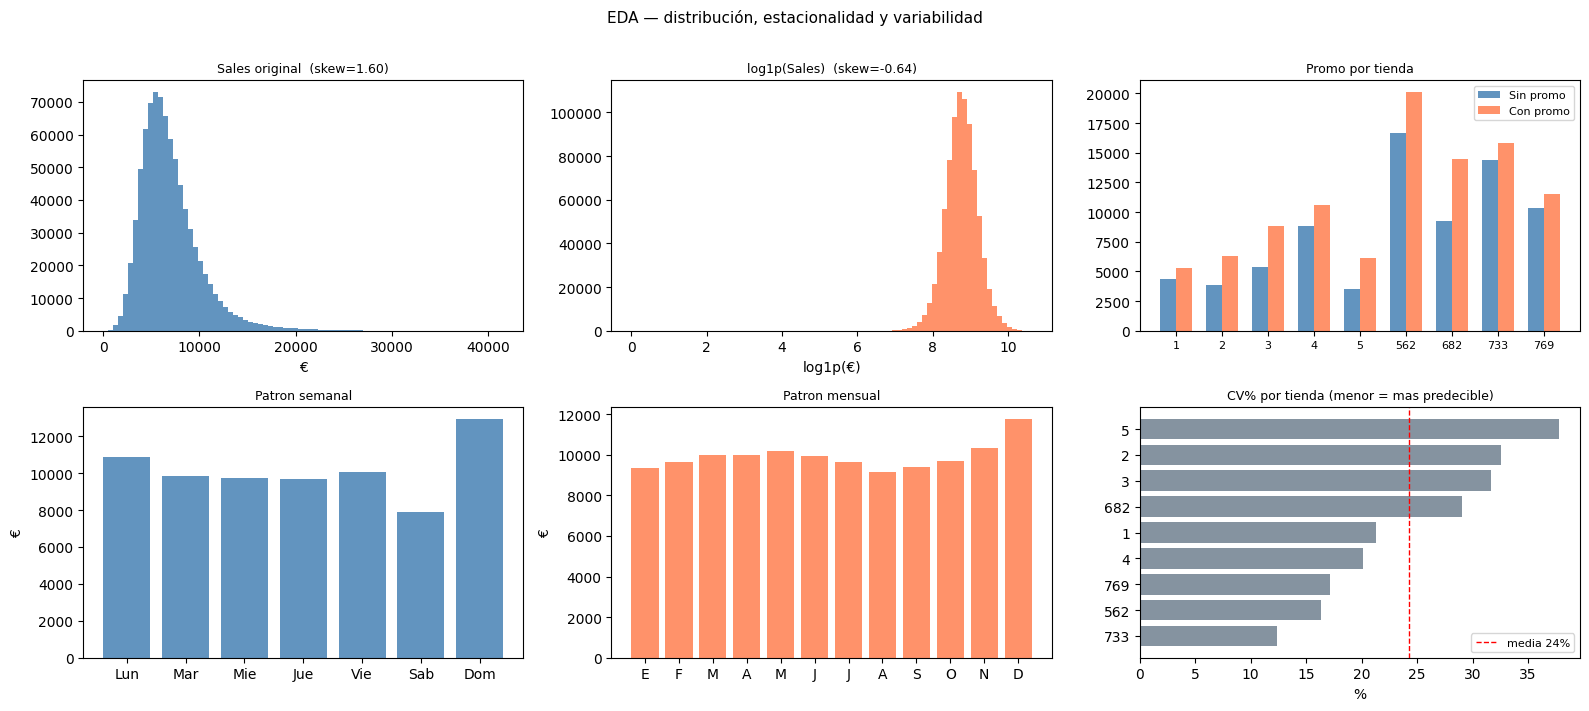

In [4]:
# Distribucion del target + patrones ciclicos + efecto promo en un solo lienzo
fig, axes = plt.subplots(2, 3, figsize=(16, 7))

sales = train_raw.loc[train_raw['Open'] == 1, 'Sales']
log_s = np.log1p(sales)

# [0,0] Sales original
axes[0,0].hist(sales, bins=80, color='steelblue', alpha=.85, edgecolor='none')
axes[0,0].set_title(f'Sales original  (skew={sales.skew():.2f})', fontsize=9)
axes[0,0].set_xlabel('€')

# [0,1] log1p(Sales)
axes[0,1].hist(log_s, bins=80, color='coral', alpha=.85, edgecolor='none')
axes[0,1].set_title(f'log1p(Sales)  (skew={log_s.skew():.2f})', fontsize=9)
axes[0,1].set_xlabel('log1p(€)')

# [0,2] Media de ventas por tienda con/sin promo
promo_store = tgt.groupby(['Store', 'Promo'])['Sales'].mean().unstack()
x = np.arange(len(promo_store))
w = 0.35
axes[0,2].bar(x - w/2, promo_store[0], w, label='Sin promo', color='steelblue', alpha=.85)
axes[0,2].bar(x + w/2, promo_store[1], w, label='Con promo',  color='coral',     alpha=.85)
axes[0,2].set_xticks(x); axes[0,2].set_xticklabels(promo_store.index, fontsize=8)
axes[0,2].set_title('Promo por tienda', fontsize=9)
axes[0,2].legend(fontsize=8)

# [1,0] Patron semanal
by_day = tgt.groupby('DayOfWeek')['Sales'].mean()
axes[1,0].bar(range(7), by_day.values, color='steelblue', alpha=.85)
axes[1,0].set_xticks(range(7))
axes[1,0].set_xticklabels(['Lun','Mar','Mie','Jue','Vie','Sab','Dom'])
axes[1,0].set_title('Patron semanal', fontsize=9); axes[1,0].set_ylabel('€')

# [1,1] Patron mensual
by_month = tgt.assign(mes=tgt['Date'].dt.month).groupby('mes')['Sales'].mean()
axes[1,1].bar(range(12), by_month.values, color='coral', alpha=.85)
axes[1,1].set_xticks(range(12))
axes[1,1].set_xticklabels(['E','F','M','A','M','J','J','A','S','O','N','D'])
axes[1,1].set_title('Patron mensual', fontsize=9); axes[1,1].set_ylabel('€')

# [1,2] CV% por tienda (variabilidad relativa)
cv = (tgt.groupby('Store')['Sales'].std() / tgt.groupby('Store')['Sales'].mean() * 100).sort_values()
axes[1,2].barh(cv.index.astype(str), cv.values, color='slategray', alpha=.85)
axes[1,2].set_title('CV% por tienda (menor = mas predecible)', fontsize=9)
axes[1,2].set_xlabel('%')
axes[1,2].axvline(cv.mean(), color='red', lw=1, ls='--', label=f'media {cv.mean():.0f}%')
axes[1,2].legend(fontsize=8)

plt.suptitle('EDA — distribución, estacionalidad y variabilidad', fontsize=11, y=1.01)
plt.tight_layout(); plt.show()

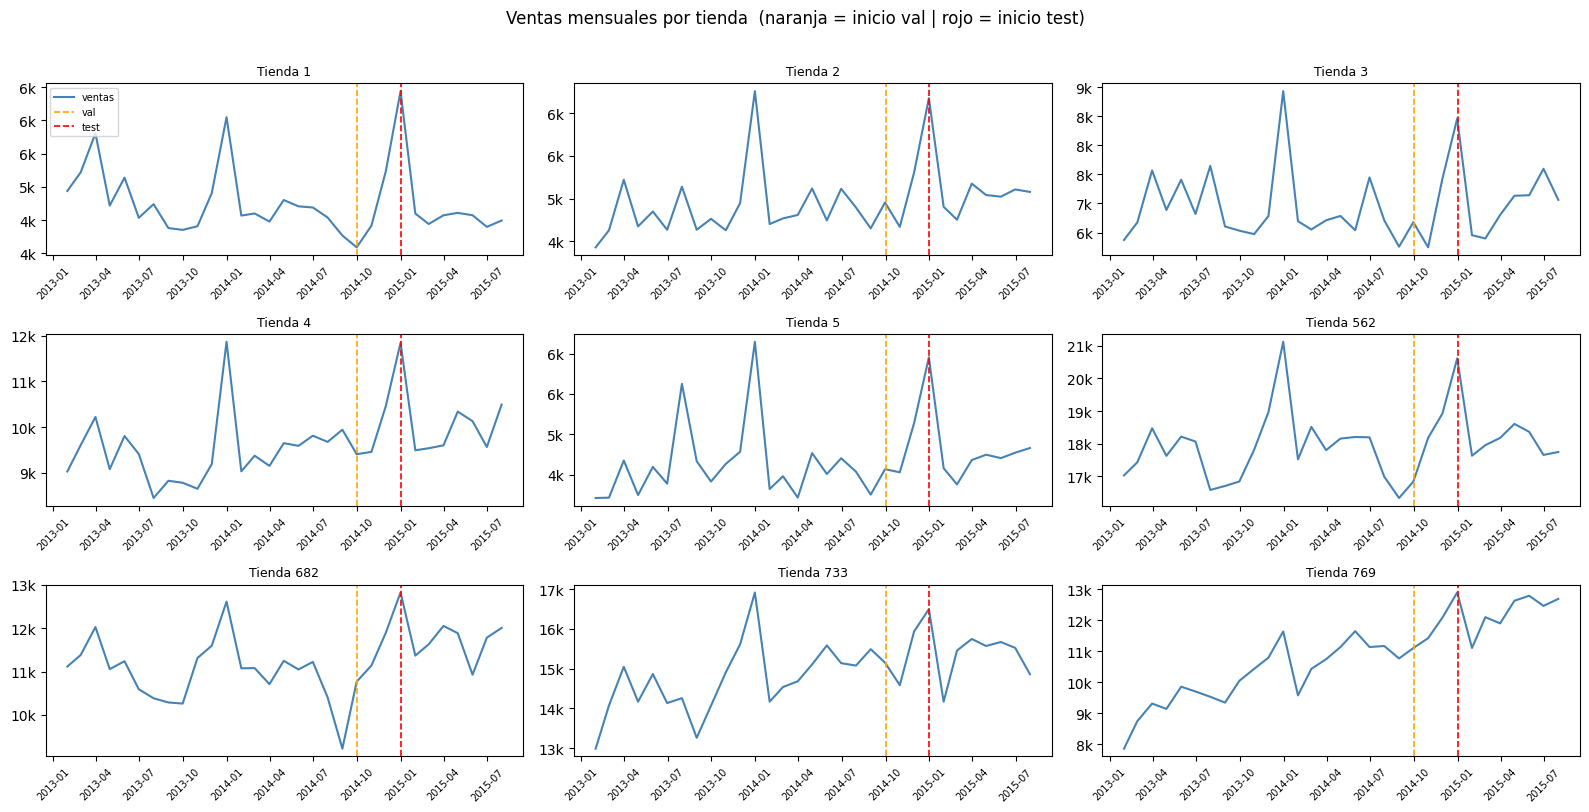

In [5]:
# Series temporales mensuales de las 9 tiendas (lineas: inicio val/test)
fig, axes = plt.subplots(3, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, sid in zip(axes, ev.TARGET_STORES):
    ts = (
        train_raw[(train_raw['Store'] == sid) & (train_raw['Open'] == 1)]
        .sort_values('Date').set_index('Date')['Sales']
        .resample('ME').mean()
    )
    ax.plot(ts.index, ts.values, lw=1.5, color='steelblue')
    ax.axvline(ev.SPLIT_VAL_START,  color='orange', lw=1.2, ls='--')
    ax.axvline(ev.SPLIT_TEST_START, color='red',    lw=1.2, ls='--')
    ax.set_title(f'Tienda {sid}', fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

axes[0].legend(['ventas', 'val', 'test'], fontsize=7, loc='upper left')
plt.suptitle('Ventas mensuales por tienda  (naranja = inicio val | rojo = inicio test)', y=1.01)
plt.tight_layout(); plt.show()

### Conclusiones del EDA

#### Datos
- `train.csv` sin nulos. `store.csv`: **CompetitionOpenSince\* nulo en 354 tiendas** (sin competencia conocida → imputar con 0); **PromoInterval nulo en 544** (sin Promo2 → imputar como `'None'`); solo 3 nulos en `CompetitionDistance` → mediana 2.325 m.
- `clean_train` descarta el **17,0 %** (170.627 días cerrados) + 54 anomalías → **830.918 filas útiles**.

#### Target
- `Sales` tiene skew **1,60** — cola derecha muy larga. `log1p` la elimina casi completamente, confirmando la elección del target.
- Z-score por tienda es imprescindible: tienda 562 vende de media **3,8× más** que tienda 1 (€17.980 vs €4.763). Sin normalización por tienda, el gradiente estaría dominado por las tiendas grandes.

#### Features más relevantes
| Feature | Impacto observado |
|---|---|
| `Store` (embedding) | Mayor fuente de varianza — escalas radicalmente distintas |
| `Promo` | **+22 % de ventas** en las 9 tiendas objetivo |
| `DayOfWeek` | Patrón semanal claro; domingo casi ausente en tiendas 1-5 |
| `month` | Pico en diciembre, caída en enero — capturado por la validación oct-dic |
| `days_since_start` | Tienda 769 muestra tendencia alcista visible en su serie — crítico para el test |

#### Las 9 tiendas objetivo
- **Tiendas 1-5**: StoreType a/c, ~769 días de train, cierran domingos → dataset **más escaso**.
- **Tiendas 562/682/733/769**: StoreType b (las 4), abren 7 días → **928 días de train**, 20 % más datos.
- **Tienda 682**: competencia a solo **150 m** (la más agresiva del grupo).
- **Más difíciles de predecir** (CV% alto): Tienda 5 (37,8 %) y Tienda 2 (32,6 %).
- **Más predecible** (CV% bajo): Tienda 733 (12,3 %).

#### Implicaciones de diseño confirmadas
- **Modelo global con Store Embedding** correcto: tiendas 1-5 con ~769 días son insuficientes para modelos independientes.
- **Validación oct-dic 2014** captura el pico navideño → exigente y representativa.
- **`SEQ_LEN = 30`** captura ~6 semanas → cubre patrones semanales y quincenales.

## 2 · Partición temporal

Las fechas de corte están definidas en `src/evaluate.py` como contrato del equipo.  
**No redefinir aquí.**

In [6]:
print(f"Train:  hasta            {ev.SPLIT_TRAIN_END.date()}")
print(f"Val:    {ev.SPLIT_VAL_START.date()} → {ev.SPLIT_VAL_END.date()}")
print(f"Test:   {ev.SPLIT_TEST_START.date()} → 2015-07-17   ← evaluado por el profesor")
print(f"Tiendas objetivo: {ev.TARGET_STORES}")

Train:  hasta            2014-09-30
Val:    2014-10-01 → 2014-12-31
Test:   2015-01-01 → 2015-07-17   ← evaluado por el profesor
Tiendas objetivo: [1, 2, 3, 4, 5, 562, 682, 733, 769]


## 3 · Preprocesado

Implementado en `src/preprocessing.py`. Ejecutar en el orden definido por el docstring del módulo.

In [7]:
# Limpieza: elimina Open==0 y Sales==0 con Open==1
df = prep.clean_train(train_raw)
print(f"Filas tras clean_train: {len(df):,}  (eliminadas: {len(train_raw)-len(df):,})")

Filas tras clean_train: 830,918  (eliminadas: 170,681)


In [8]:
# Merge store.csv + imputación de nulos
df = prep.merge_store_features(df, store_raw)
print(f"Columnas tras merge: {list(df.columns)}")

Columnas tras merge: ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'Id', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']


c:\Users\Usuario\Downloads\TAREA_ENTRADAS_HETEROGENEAS\src\preprocessing.py:84: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["CompetitionDistance"].fillna(df["CompetitionDistance"].median(), inplace=True)
c:\Users\Usuario\Downloads\TAREA_ENTRADAS_HETEROGENEAS\src\preprocessing.py:85: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on wh

In [9]:
# Label-encoding de categóricas
df, cat_encoders = prep.encode_categoricals(df)
print(f"Encoders: {list(cat_encoders.keys())}")

Encoders: ['Store', 'StoreType', 'Assortment', 'PromoInterval', 'StateHoliday']


In [10]:
# Features temporales y de competencia
df = prep.engineer_features(df)
print(f"Columnas totales: {df.shape[1]}")

Columnas totales: 34


In [11]:
# Split temporal
df_train, df_val, df_test = prep.temporal_split(df)
print(f"Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}")

Train: 577,527 | Val: 70,782 | Test: 182,609


In [12]:
# Normalización por tienda — fit SOLO sobre df_train
store_stats = prep.build_store_normalizer(df_train)
df_train = prep.normalize_sales(df_train, store_stats)
df_val   = prep.normalize_sales(df_val,   store_stats)
df_test  = prep.normalize_sales(df_test,  store_stats)

# Verificar que Sales_norm tiene media ~0 y std ~1 en train
print("Sales_norm en train — media por tienda (primeras 5):")
print(df_train.groupby("Store")["Sales_norm"].mean().head())

Sales_norm en train — media por tienda (primeras 5):
Store
1   -2.024309e-09
2    4.761649e-10
3   -1.577439e-09
4    4.481552e-10
5   -9.225199e-10
Name: Sales_norm, dtype: float32


In [13]:
SEQ_LEN = 30

X_seq_tr, X_static_tr, y_tr = prep.build_sequences(df_train, SEQ_LEN)
X_seq_va, X_static_va, y_va = prep.build_sequences(df_val,   SEQ_LEN)
X_seq_te, X_static_te, y_te = prep.build_sequences(df_test,  SEQ_LEN)

print(f"X_seq   train: {X_seq_tr.shape}    | dtype: {X_seq_tr.dtype}")
print(f"X_static train: {X_static_tr.shape} | dtype: {X_static_tr.dtype}")
print(f"y        train: {y_tr.shape}")

X_seq   train: (544077, 30, 11)    | dtype: float32
X_static train: (544077, 8) | dtype: float32
y        train: (544077,)


## 4 · Modelo

Arquitectura definida en `src/model.py`. Rama LSTM + rama densa con embeddings.

In [14]:
model = mdl.build_model(
    n_stores=df["Store"].nunique(),
    seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr.shape[-1],
    n_static_num_features=len(prep.STATIC_NUM_COLS),
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ static (InputLayer) │ (None, 8)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 1)         │          0 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 1)         │          0 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 1)         │          0 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 1)         │          0 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_Store_enc       │ (None, 1, 16)     │     17,840 │ lambda[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_StoreType_enc   │ (None, 1, 2)      │          8 │ lambda_1[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_Assortment_enc  │ (None, 1, 2)      │          6 │ lambda_2[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_PromoInterval_… │ (None, 1, 2)      │          8 │ lambda_3[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seq (InputLayer)    │ (None, 30, 11)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 16)        │          0 │ emb_Store_enc[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 2)         │          0 │ emb_StoreType_en… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 2)         │          0 │ emb_Assortment_e… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 2)         │          0 │ emb_PromoInterva… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_4 (Lambda)   │ (None, 4)         │          0 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     19,456 │ seq[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 26)        │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0],  │
│                     │                   │            │ flatten_2[0][0],  │
│                     │                   │            │ flatten_3[0][0],  │
│                     │                   │            │ lambda_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      1,728 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,160 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]   

 Total params: 59,847 (233.78 KB)

 Trainable params: 59,847 (233.78 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
callbacks = mdl.get_callbacks(
    checkpoint_path=os.path.join(OUTPUTS_DIR, "best_model.weights.h5")
)

history = mdl.train_model(
    model,
    X_train=(X_seq_tr, X_static_tr), y_train=y_tr,
    X_val=(X_seq_va, X_static_va),   y_val=y_va,
    callbacks=callbacks,
    epochs=50,
    batch_size=256,
)

Epoch 1/50
2124/2126 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.7744

2126/2126 ━━━━━━━━━━━━━━━━━━━━ 60s 27ms/step - loss: 0.6044 - val_loss: 0.8442 - learning_rate: 0.0010
Epoch 2/50
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 60s 28ms/step - loss: 0.3219 - val_loss: 1.0363 - learning_rate: 0.0010
Epoch 3/50
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 60s 28ms/step - loss: 0.2754 - val_loss: 0.9112 - learning_rate: 0.0010
Epoch 4/50
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 58s 27ms/step - loss: 0.2555 - val_loss: 1.1217 - learning_rate: 0.0010
Epoch 5/50
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 58s 27ms/step - loss: 0.2428 - val_loss: 1.1586 - learning_rate: 0.0010
Epoch 6/50
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 60s 28ms/step - loss: 0.2354 - val_loss: 1.0705 - learning_rate: 0.0010
Epoch 7/50
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 60s 28ms/step - loss: 0.2206 - val_loss: 1.1290 - learning_rate: 5.0000e-04
Epoch 8/50
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 60s 28ms/step - loss: 0.2167 - val_loss: 1.1171 - learning_rate: 5.0000e-04
Epoch 9/50
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 59s 28ms/step - loss: 0.2144 - val_loss: 1.1384 -

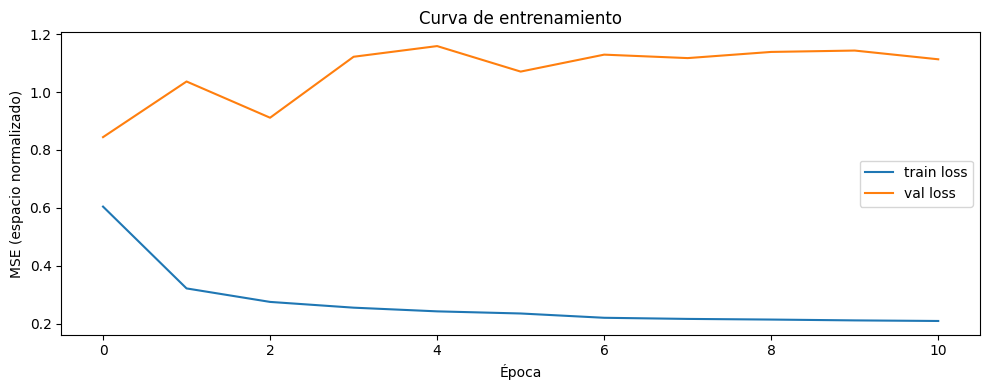

In [16]:
# Curva de aprendizaje
plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"],     label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Época")
plt.ylabel("MSE (espacio normalizado)")
plt.legend()
plt.title("Curva de entrenamiento")
plt.tight_layout()
plt.show()

## 5 · Evaluación

R² calculado con `src/evaluate.py` — misma función para los tres miembros del equipo.

In [17]:
y_pred_norm = model.predict([X_seq_te, X_static_te], verbose=0).flatten()

KeyboardInterrupt: 

In [ ]:
report = ev.evaluation_report(df_test, y_pred_norm, store_stats)
display(report)

## 6 · Log de experimentos

Anotar aquí cada experimento antes de hacer `git push`.

| # | Fecha | Cambio principal | R² val | R² test global | Notas |
|---|-------|-----------------|--------|----------------|-------|
| 1 |       | Baseline         |        |                |       |

---
### Plantilla de nota de experimento

**Experimento #N**  
- Fecha:  
- Cambios: `(p.ej. SEQ_LEN=60, lstm_units=128)`  
- R² val:  
- R² test por tienda: *(copiar tabla del report)*  
- Observaciones: